In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [8]:
df = pd.read_csv('airline_tweets.csv')

In [9]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [10]:
df.describe()

,tweet_id,airline_sentiment_confidence,negativereason_confidence,retweet_count
count,1.464000e+04,14640.000000,10522.000000,14640.000000
mean,5.692184e+17,0.900169,0.638298,0.082650
std,7.791112e+14,0.162830,0.330440,0.745778
min,5.675883e+17,0.335000,0.000000,0.000000
25%,5.685592e+17,0.692300,0.360600,0.000000
50%,5.694779e+17,1.000000,0.670600,0.000000
75%,5.698905e+17,1.000000,1.000000,0.000000
max,5.703106e+17,1.000000,1.000000,44.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [12]:
df['text']

0                      @VirginAmerica What @dhepburn said.
1        @VirginAmerica plus you've added commercials t...
2        @VirginAmerica I didn't today... Must mean I n...
3        @VirginAmerica it's really aggressive to blast...
4        @VirginAmerica and it's a really big bad thing...
                               ...                        
14635    @AmericanAir thank you we got on a different f...
14636    @AmericanAir leaving over 20 minutes Late Flig...
14637    @AmericanAir Please bring American Airlines to...
14638    @AmericanAir you have my money, you change my ...
14639    @AmericanAir we have 8 ppl so we need 2 know h...
Name: text, Length: 14640, dtype: object

In [13]:
df['text'][1]

"@VirginAmerica plus you've added commercials to the experience... tacky."

In [15]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

<Axes: xlabel='airline_sentiment', ylabel='count'>

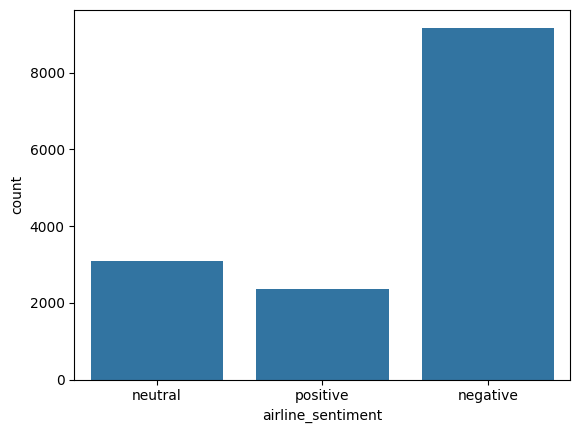

In [17]:
sns.countplot(data = df, x = 'airline_sentiment')

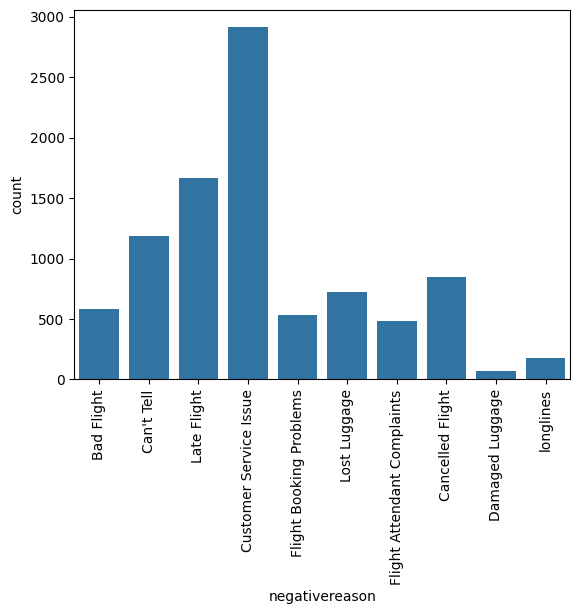

In [19]:
sns.countplot(data = df, x = 'negativereason')
plt.xticks(rotation = 90)
plt.show()

<Axes: xlabel='airline', ylabel='count'>

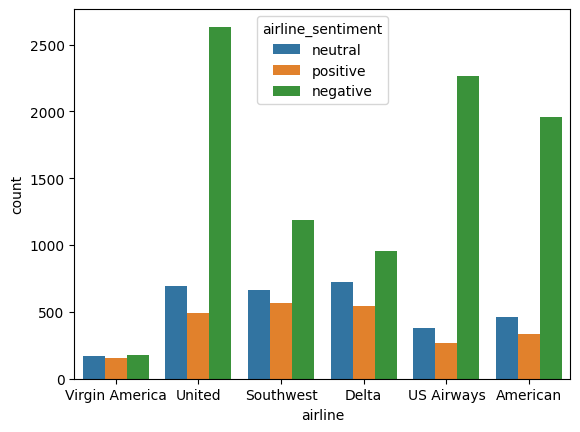

In [20]:
sns.countplot(data = df, x = 'airline', hue = 'airline_sentiment')

In [22]:
df['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

### Features and Labels :

In [25]:
df[['airline_sentiment', 'text']]

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...
...,...,...
14635,positive,@AmericanAir thank you we got on a different f...
14636,negative,@AmericanAir leaving over 20 minutes Late Flig...
14637,neutral,@AmericanAir Please bring American Airlines to...
14638,negative,"@AmericanAir you have my money, you change my ..."


In [26]:
data = df[['airline_sentiment', 'text']]

In [27]:
data.head()

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


In [29]:
X = data['text']
y = data['airline_sentiment']

### Train test split:

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state= 101)

### Vectiorization: 

### TF-IDF and `TfidfVectorizer`

The **`TfidfVectorizer`** from `sklearn.feature_extraction.text` does not just assign weights based only on frequency.  
It assigns weights using **TF-IDF (Term Frequency – Inverse Document Frequency)**.

---

#### 1. Term Frequency (TF)  
Measures how often a word appears in a document.  
It is usually normalized by the total number of words in the document.  

\[
TF(w, d) = \frac{\text{count of word } w \text{ in document } d}{\text{total words in document } d}
\]

---

#### 2. Inverse Document Frequency (IDF)  
Down-weights words that appear in many documents (since they are less informative).  

\[
IDF(w) = \log \frac{N}{1 + df(w)}
\]

where  
- \(N\) = total number of documents  
- \(df(w)\) = number of documents containing the word \(w\)

---

#### 3. TF-IDF Weight
The final weight is the product of TF and IDF:

\[
TF\text{-}IDF(w, d) = TF(w, d) \times IDF(w)
\]

---

### Intuition
- A word that appears **often in one document but rarely across others** → **high weight**.  
- A word that appears **frequently in all documents** (e.g., *the, is, and*) → **low weight**.  

---

 So, `TfidfVectorizer` gives **higher importance to unique, document-specific words**, and **lower importance to very common words**.


In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer 

In [38]:
tfidf = TfidfVectorizer(stop_words= 'english')
tfidf.fit(X_train)

TfidfVectorizer(stop_words='english')

In [39]:
X_train_tfidf = tfidf.transform(X_train)

In [54]:
X_test_tfidf = tfidf.transform(X_test)

In [55]:
X_train_tfidf   # do not try to do : todense. 

<11712x12971 sparse matrix of type '<class 'numpy.float64'>'
	with 107073 stored elements in Compressed Sparse Row format>

### Model Building:

In [56]:
# NAive bayes: 
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

MultinomialNB()

In [57]:
# other models 
from  sklearn.linear_model import LogisticRegression
log = LogisticRegression()  # if some warning comes give manually: max_iter = 10000
log.fit(X_train_tfidf, y_train)

LogisticRegression()

In [58]:
# Other model :
from sklearn.svm import LinearSVC
svc = LinearSVC()
svc.fit(X_train_tfidf, y_train)

LinearSVC()

### Performance Evaluation: 

In [62]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [69]:
def report(model):
    print(f"{str(model)} model")
    pred = model.predict(X_test_tfidf)
    print(classification_report(y_test, pred))
    cm = confusion_matrix(pred, y_test)
    ConfusionMatrixDisplay(confusion_matrix = cm).plot()
    print(cm)

MultinomialNB() model
              precision    recall  f1-score   support

    negative       0.66      0.99      0.79      1817
     neutral       0.79      0.15      0.26       628
    positive       0.89      0.14      0.24       483

    accuracy                           0.67      2928
   macro avg       0.78      0.43      0.43      2928
weighted avg       0.73      0.67      0.59      2928

[[1807  524  399]
 [   9   97   17]
 [   1    7   67]]


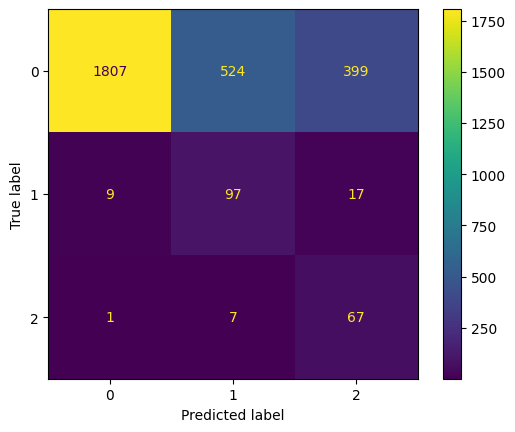

In [71]:
report(nb)

###  Conclusion: MultinomialNB Model Performance

- **Overall accuracy:** 0.67 → the model predicts correctly about **67%** of the time.

---

#### 🔹 Class-wise insights
- **Negative class**
  - Recall = **0.99** → almost all negatives are detected.  
  - Precision = **0.66** → many false positives (model over-predicts negatives).  
  - F1 = **0.79** → decent performance.  
  * Model is heavily biased toward predicting *negative*.  

- **Neutral class**
  - Recall = **0.15** → only 15% of actual neutrals are caught.  
  - Precision = **0.79** → when predicted, it is often correct, but predictions are rare.  
  - F1 = **0.26** → very poor overall performance.  

- **Positive class**
  - Recall = **0.14** → only 14% of actual positives are caught.  
  - Precision = **0.89** → predictions are correct when they occur, but occur rarely.  
  - F1 = **0.24** → poor overall performance.  

---

#### 🔹 Confusion Matrix Insights


### Logistic regression report:

LogisticRegression() model
              precision    recall  f1-score   support

    negative       0.80      0.93      0.86      1817
     neutral       0.63      0.47      0.54       628
    positive       0.81      0.58      0.68       483

    accuracy                           0.77      2928
   macro avg       0.75      0.66      0.69      2928
weighted avg       0.77      0.77      0.76      2928

[[1695  292  133]
 [ 101  293   71]
 [  21   43  279]]


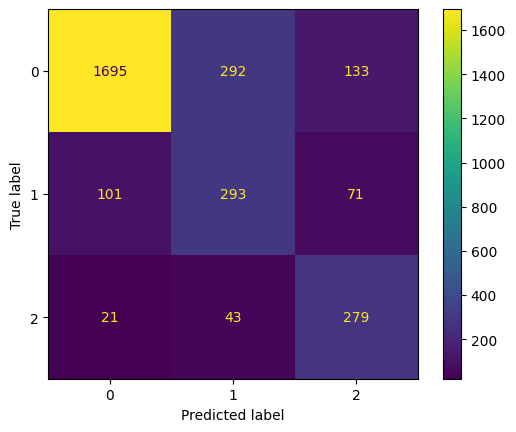

In [72]:
report(log)

LinearSVC() model
              precision    recall  f1-score   support

    negative       0.82      0.89      0.86      1817
     neutral       0.59      0.52      0.55       628
    positive       0.76      0.64      0.69       483

    accuracy                           0.77      2928
   macro avg       0.73      0.68      0.70      2928
weighted avg       0.76      0.77      0.77      2928

[[1624  240  106]
 [ 158  327   69]
 [  35   61  308]]


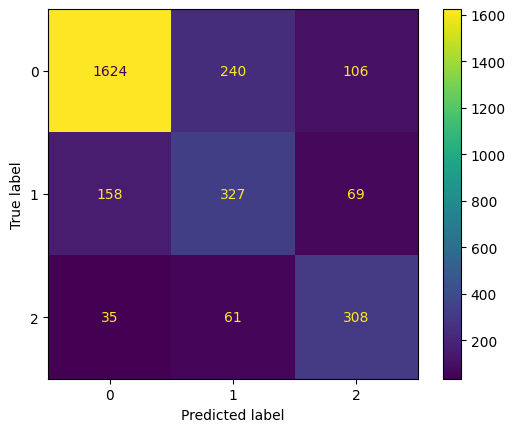

In [73]:
report(svc)

Note:
* tree based models are not suitable since we have large data set.
* We can perform grid search for above three models. That is possible to get better models. 

### Final pipeline to be deployed on new tweets: 
* we finally decided to deploy SVC model as a final one. 

In [74]:
from sklearn.pipeline import Pipeline

In [75]:
pipe = Pipeline([('tfidf', TfidfVectorizer()), ('svc',LinearSVC())])

In [77]:
pipe.fit(df['text'], df['airline_sentiment'])

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('svc', LinearSVC())])

In [78]:
new_tweet = ['good flight']
pipe.predict(new_tweet)

array(['positive'], dtype=object)

In [79]:
new_tweet = ['horrible']
pipe.predict(new_tweet)

array(['negative'], dtype=object)

In [80]:
new_tweet = ['okay']
pipe.predict(new_tweet)

array(['neutral'], dtype=object)

In [81]:
new_tweet = ['could be better']
pipe.predict(new_tweet)

array(['negative'], dtype=object)

In [82]:
new_tweet = ['can be improved']
pipe.predict(new_tweet)

array(['neutral'], dtype=object)

In [84]:
new_tweet = ['I would travel again with your airline']
pipe.predict(new_tweet)

array(['negative'], dtype=object)

In [85]:
new_tweet = ['I would love travel again with your airline']
pipe.predict(new_tweet)

array(['positive'], dtype=object)